# Ayan's Emotion Detector — Transfer Learning with PyTorch

**Model:** ResNet18 pre-trained on ImageNet, fine-tuned on FER2013  
**Task:** 7-class facial expression recognition: Angry, Disgust, Fear, Happy, Sad, Surprise, Neutral  
**Goal:** Real-time detection via Flask + OpenCV

---
### Dataset Setup
Download FER2013 from Kaggle:
```
kaggle competitions download -c challenges-in-representation-learning-facial-expression-recognition-challenge
```
Or manually from: https://www.kaggle.com/datasets/msambare/fer2013

Extract so your folder looks like:
```
data/
  train/
    angry/  disgust/  fear/  happy/  sad/  surprise/  neutral/
  test/
    angry/  disgust/  fear/  happy/  sad/  surprise/  neutral/
```

In [2]:
# Install dependencies (run once)
# !pip install torch torchvision matplotlib seaborn scikit-learn tqdm

In [3]:
import os, time, copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
from model import EmotionClassifier, EMOTIONS

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'Emotions: {EMOTIONS}')

Using device: cpu
Emotions: ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']


## 1. Data Loading & Augmentation

In [5]:
DATA_DIR  = 'data'          # change if your path differs
BATCH_SIZE = 64
IMG_SIZE   = 224

train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), transform=train_transforms)
val_ds   = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'),  transform=val_transforms)

# Weighted sampler to handle class imbalance (FER2013 is imbalanced)
class_counts = np.array([len(os.listdir(os.path.join(DATA_DIR, 'train', c)))
                         for c in train_ds.classes])
weights      = 1.0 / class_counts
sample_weights = weights[train_ds.targets]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_ds)} samples | Val: {len(val_ds)} samples')
print(f'Classes: {train_ds.classes}')

Train: 28709 samples | Val: 7178 samples
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


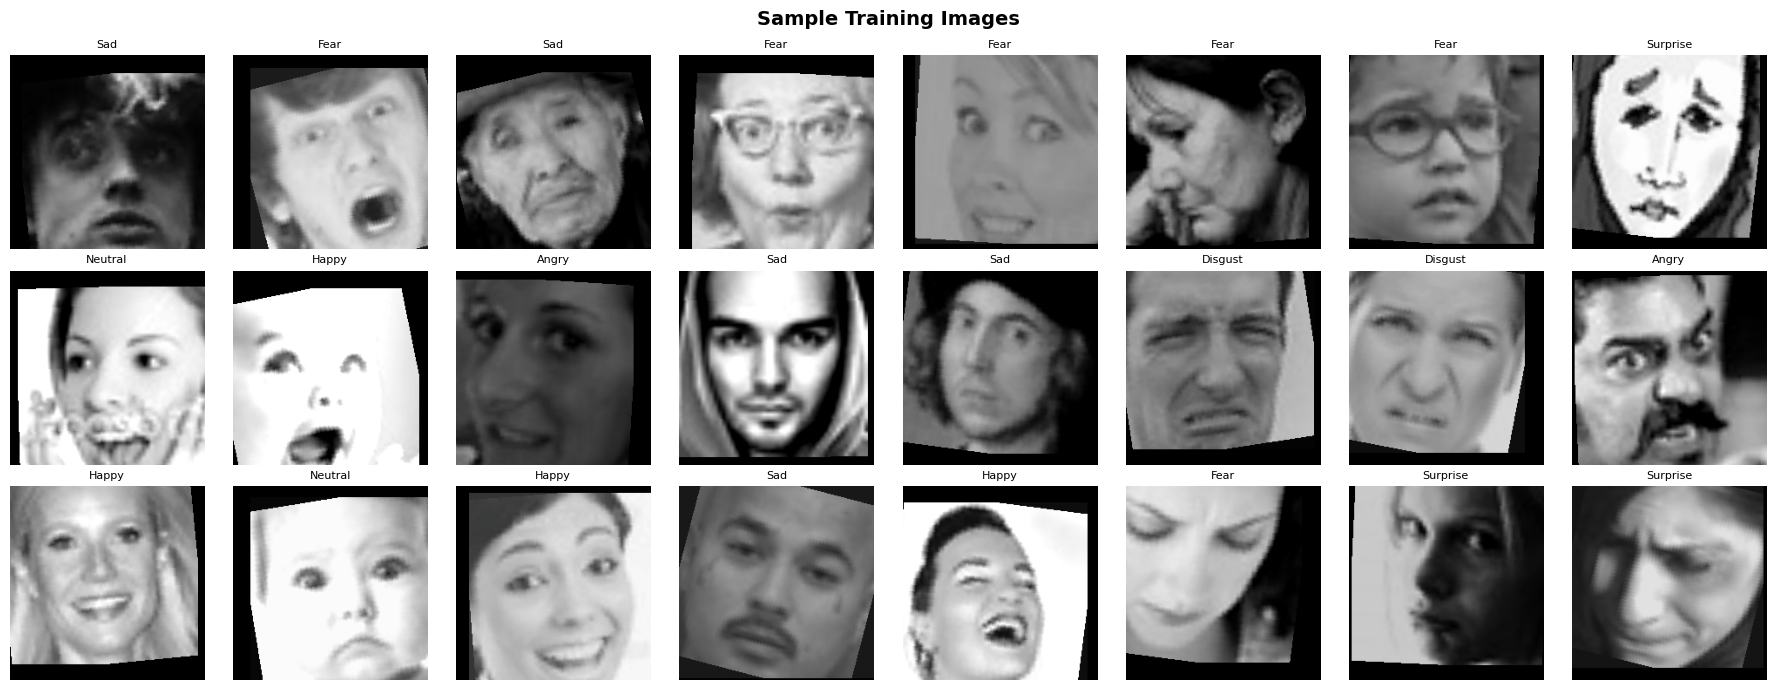

In [6]:
# Visualise a batch of training images
def denorm(t):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return (t * std + mean).clamp(0, 1)

imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(3, 8, figsize=(18, 7))
for i, ax in enumerate(axes.flatten()):
    if i >= len(imgs): break
    img = denorm(imgs[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(EMOTIONS[labels[i]], fontsize=8)
    ax.axis('off')
plt.suptitle('Sample Training Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Build the Model (ResNet18 Transfer Learning)

In [8]:
model = EmotionClassifier(pretrained=True, freeze_backbone=False).to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params:     {total:,}')
print(f'Trainable params: {trainable:,}')
print('\nBackbone layers:')
for i, layer in enumerate(model.backbone):
    print(f'  [{i}] {layer.__class__.__name__}')
print('\nClassifier head:')
print(model.classifier)

Total params:     11,309,639
Trainable params: 11,309,639

Backbone layers:
  [0] Conv2d
  [1] BatchNorm2d
  [2] ReLU
  [3] MaxPool2d
  [4] Sequential
  [5] Sequential
  [6] Sequential
  [7] Sequential
  [8] AdaptiveAvgPool2d

Classifier head:
Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=512, out_features=256, bias=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=256, out_features=7, bias=True)
)


## 3. Training

In [10]:
EPOCHS    = 30
LR        = 3e-4
LR_MIN    = 1e-6

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR_MIN)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_acc   = 0.0
best_weights = copy.deepcopy(model.state_dict())

def run_epoch(loader, training=True):
    model.train(training)
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad if training else torch.no_grad
    with ctx():
        for imgs, labels in tqdm(loader, leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if training:
                optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, labels)
            if training:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            preds  = logits.argmax(1)
            correct += (preds == labels).sum().item()
            total   += imgs.size(0)
    return total_loss / total, correct / total

print('Training started...')
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    vl_loss, vl_acc = run_epoch(val_loader,   training=False)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    elapsed = time.time() - t0
    print(f'Epoch {epoch:02d}/{EPOCHS} | '
          f'Train Loss: {tr_loss:.4f} Acc: {tr_acc*100:.2f}% | '
          f'Val Loss: {vl_loss:.4f} Acc: {vl_acc*100:.2f}% | '
          f'{elapsed:.1f}s')

    if vl_acc > best_acc:
        best_acc     = vl_acc
        best_weights = copy.deepcopy(model.state_dict())
        torch.save(best_weights, 'emotion_model.pth')
        print(f'  ✓ Best model saved! Val Acc: {best_acc*100:.2f}%')

print(f'\nTraining complete. Best Val Acc: {best_acc*100:.2f}%')

Training started...


Epoch 01/30 | Train Loss: 1.4131 Acc: 52.38% | Val Loss: 1.2772 Acc: 59.18% | 1796.6s
  ✓ Best model saved! Val Acc: 59.18%


Epoch 02/30 | Train Loss: 1.2090 Acc: 63.67% | Val Loss: 1.2171 Acc: 62.69% | 1917.0s
  ✓ Best model saved! Val Acc: 62.69%


Epoch 03/30 | Train Loss: 1.1353 Acc: 67.29% | Val Loss: 1.1816 Acc: 64.63% | 1740.6s
  ✓ Best model saved! Val Acc: 64.63%


Epoch 04/30 | Train Loss: 1.0909 Acc: 69.84% | Val Loss: 1.2203 Acc: 63.68% | 3122.2s


...

Epoch 28/30 | Train Loss: 0.5710 Acc: 95.63% | Val Loss: 1.2497 Acc: 69.70% | 1612.1s


  0%|                                                   | 0/449 [00:00<?, ?it/s]python(61689) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(61690) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
  0%|                                                   | 0/113 [00:00<?, ?it/s]python(62765) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(62766) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Epoch 29/30 | Train Loss: 0.5679 Acc: 95.59% | Val Loss: 1.2466 Acc: 69.78% | 1611.8s


  0%|                                                   | 0/449 [00:00<?, ?it/s]python(62880) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(62882) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
  0%|                                                   | 0/113 [00:00<?, ?it/s]python(63905) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63916) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
                                                                                

Epoch 30/30 | Train Loss: 0.5700 Acc: 95.50% | Val Loss: 1.2485 Acc: 69.78% | 1628.7s

Training complete. Best Val Acc: 70.17%


## 4. Training Curves

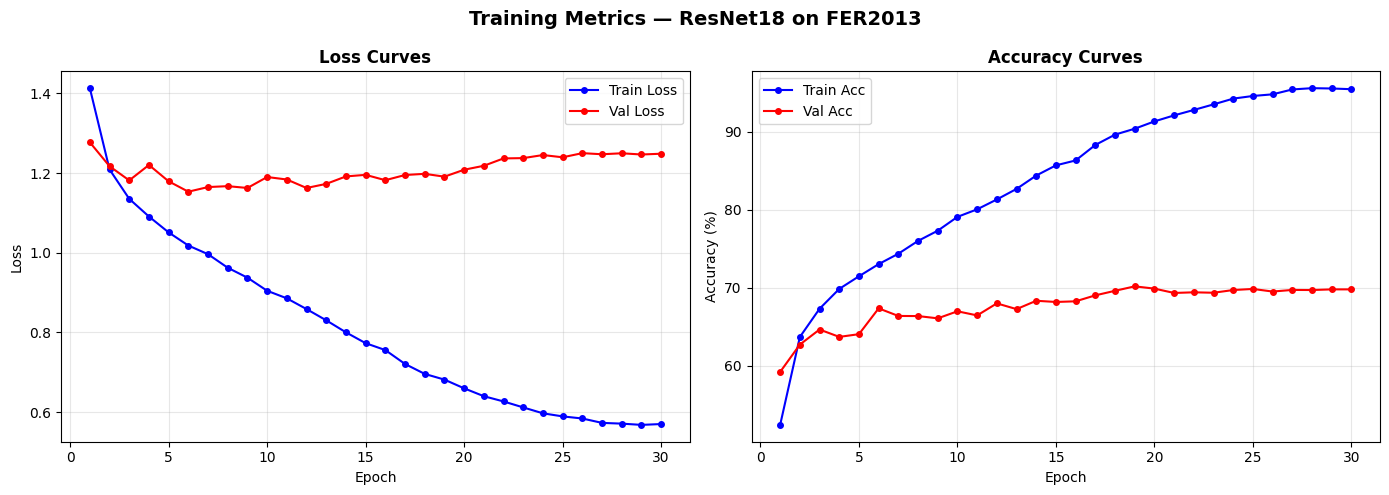

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
ax1.plot(epochs_range, history['val_loss'],   'r-o', label='Val Loss',   markersize=4)
ax1.set_title('Loss Curves', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_range, [a*100 for a in history['train_acc']], 'b-o', label='Train Acc', markersize=4)
ax2.plot(epochs_range, [a*100 for a in history['val_acc']],   'r-o', label='Val Acc',   markersize=4)
ax2.set_title('Accuracy Curves', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Training Metrics — ResNet18 on FER2013', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Evaluation — Confusion Matrix & Classification Report

Evaluating:   0%|                                       | 0/113 [00:00<?, ?it/s]python(64045) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(64047) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Evaluating: 100%|█████████████████████████████| 113/113 [02:48<00:00,  1.49s/it]



Classification Report
              precision    recall  f1-score   support

       Angry       0.59      0.65      0.62       958
     Disgust       0.87      0.68      0.76       111
        Fear       0.60      0.51      0.56      1024
       Happy       0.91      0.87      0.89      1774
         Sad       0.63      0.70      0.67      1233
    Surprise       0.57      0.58      0.57      1247
     Neutral       0.82      0.83      0.82       831

    accuracy                           0.70      7178
   macro avg       0.71      0.69      0.70      7178
weighted avg       0.71      0.70      0.70      7178



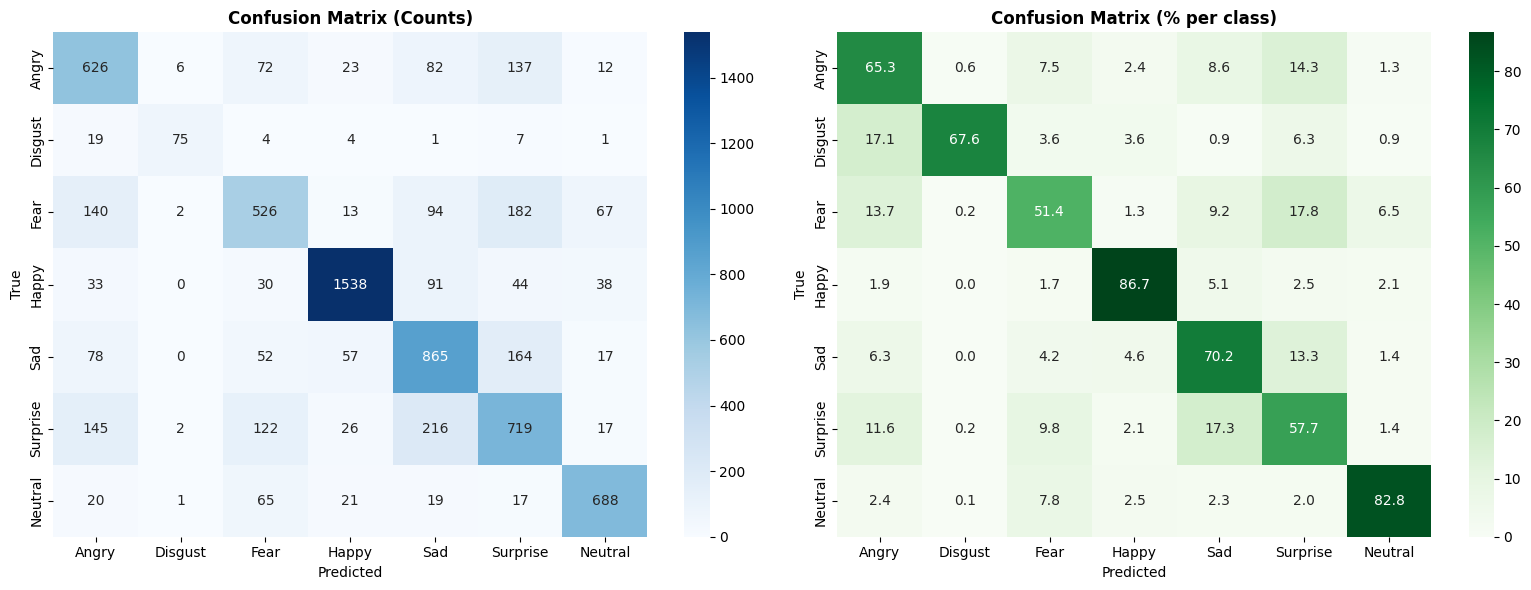

In [14]:
from model import load_model

model, _ = load_model('emotion_model.pth', DEVICE)

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for imgs, labels in tqdm(val_loader, desc='Evaluating'):
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print('\n' + '='*60)
print('Classification Report')
print('='*60)
print(classification_report(all_labels, all_preds, target_names=EMOTIONS))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=ax1)
ax1.set_title('Confusion Matrix (Counts)', fontweight='bold')
ax1.set_ylabel('True'); ax1.set_xlabel('Predicted')

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Greens',
            xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=ax2)
ax2.set_title('Confusion Matrix (% per class)', fontweight='bold')
ax2.set_ylabel('True'); ax2.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Visualise Predictions on Real Validation Samples

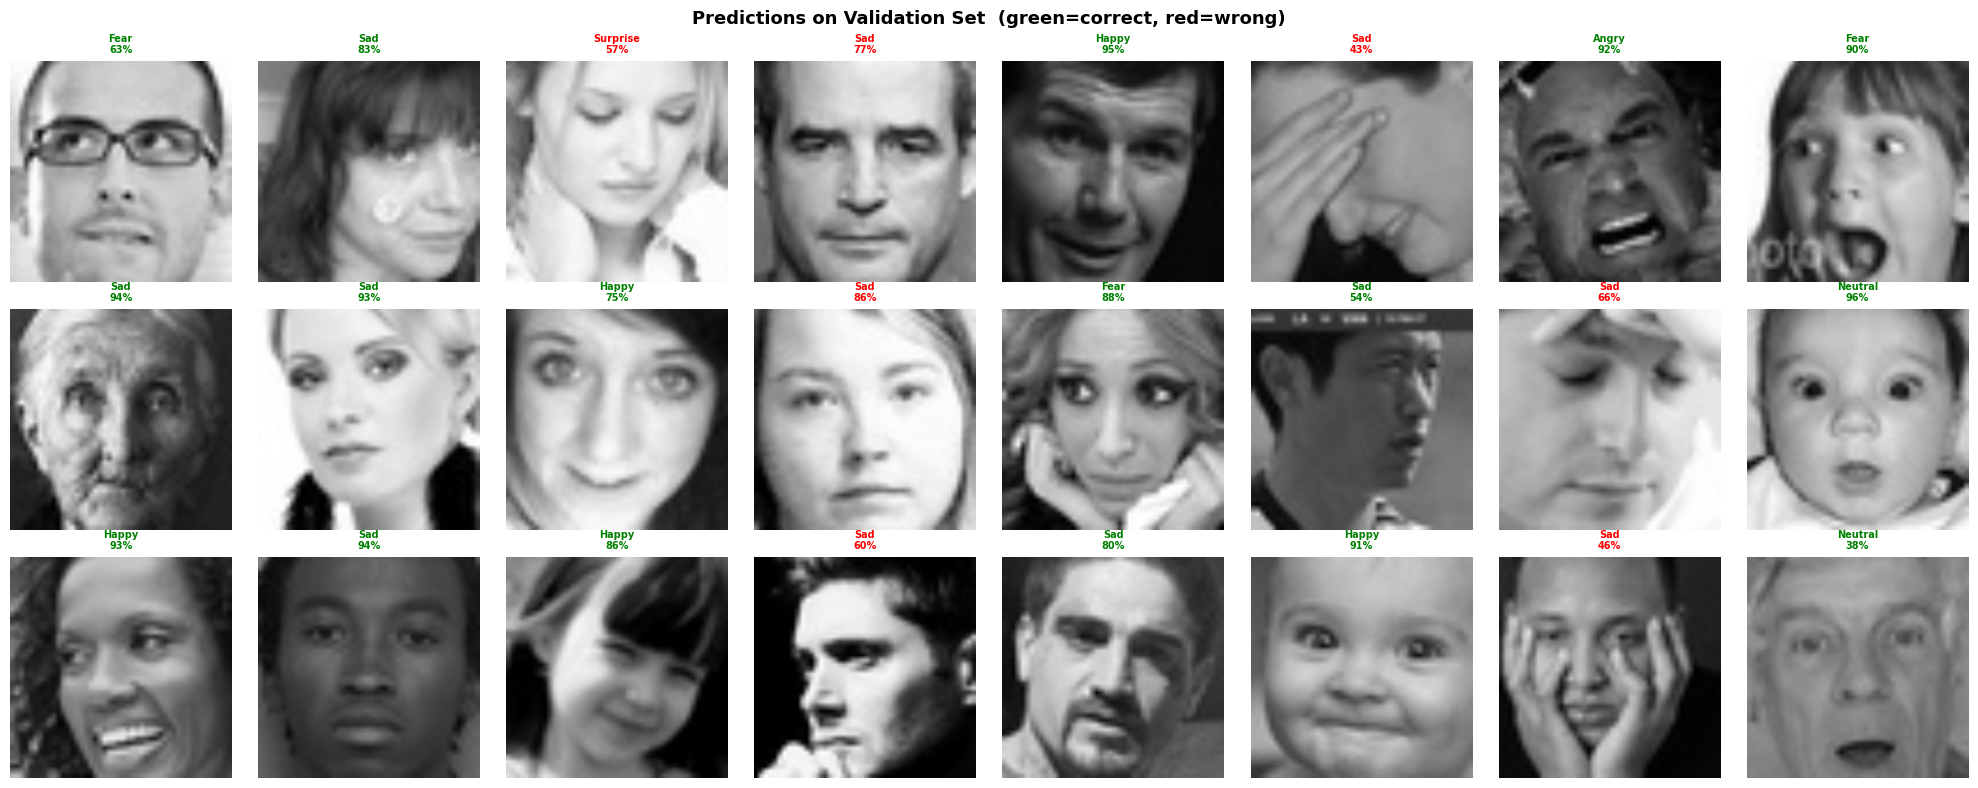

In [16]:
import random

fig, axes = plt.subplots(3, 8, figsize=(20, 8))
model.eval()

sample_indices = random.sample(range(len(val_ds)), 24)
with torch.no_grad():
    for i, idx in enumerate(sample_indices):
        img_t, true_label = val_ds[idx]
        logits = model(img_t.unsqueeze(0).to(DEVICE))
        probs  = torch.softmax(logits, 1)
        conf, pred = probs.max(1)

        ax = axes[i // 8][i % 8]
        img = denorm(img_t).permute(1, 2, 0).numpy()
        ax.imshow(img)
        color = 'green' if pred.item() == true_label else 'red'
        ax.set_title(f'{EMOTIONS[pred.item()]}\n{conf.item()*100:.0f}%',
                     fontsize=7, color=color, fontweight='bold')
        ax.axis('off')

plt.suptitle('Predictions on Validation Set  (green=correct, red=wrong)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Launch the Flask App

Model trained and saved as `emotion_model.pth`!  
Now run the Flask app from a terminal:

```bash
python app.py
```

Then open **http://localhost:5000** in your browser 🚀

In [18]:
# Optional: launch from notebook (blocks the cell)
# import subprocess
# subprocess.Popen(['python', 'app.py'])
print('Run: python app.py   then open http://localhost:5000')

Run: python app.py   then open http://localhost:5000
